# Full Pipeline Evaluation

**Prompt**: `minimal_multi` (no hints) — detect ALL violations per file  
**Model**: phi4:14b  
**Baselines**:
- B1 (LLM-only): prompt = role + code + categories + output format
- B2 (LLM+RAG): prompt = role + retrieved guidelines (S15, top-10) + code + categories + output format

**Eval set**: 106 PRs, ~1069 ground-truth reviews, 5 violation categories  
**Retrieval**: S15 production strategy (`retrieve_with_context`, BAAI/bge-large-en-v1.5, FAISS)

In [1]:
import json, sys, re, time
from pathlib import Path
from collections import Counter

ROOT = Path.cwd()
if ROOT.name != "Group-1-DS-and-AI-Lab-Project":
    ROOT = Path("/Users/kannan-14926/Documents/personal/studies/lab/Group-1-DS-and-AI-Lab-Project")

sys.path.insert(0, str(ROOT / "scripts"))

from llm_inference import infer_one, save_cache, _cache_key
from retrieve import retrieve_with_context
from evaluate_prompts import (
    build_minimal_multi_llm,
    build_minimal_multi_rag,
    _format_rag_chunks,
    _parse_json,
    _score_one,
    CATEGORIES,
)

EVAL_PATH = ROOT / "data" / "processed" / "evaluation.json"
EVAL_DIR = ROOT / "data" / "processed" / "evaluation_files"
MODEL = "phi4:14b"
NO_HINTS = {"exact_line": False, "line_range": None, "ground_truth": False}

with open(EVAL_PATH) as f:
    eval_data = json.load(f)

total_gt = sum(len(e["ground_truth_reviews"]) for e in eval_data)
cat_dist = Counter(r["violation_category"] for e in eval_data for r in e["ground_truth_reviews"])

print(f"Entries: {len(eval_data)}")
print(f"Total GT reviews: {total_gt}")
print(f"Categories: {dict(cat_dist)}")

/Users/kannan-14926/Documents/personal/studies/lab/.venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(
/Users/kannan-14926/Documents/personal/studies/lab/.venv/lib/python3.9/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Entries: 103
Total GT reviews: 721
Categories: {'unused_import': 193, 'naming_convention': 214, 'indentation': 138, 'documentation_formatting': 104, 'mutable_default': 72}


In [2]:
# Baseline 1: LLM-only (no retrieval)
llm_results = []

for i, entry in enumerate(eval_data):
    code_path = EVAL_DIR / entry["source_file"].replace("evaluation_files/", "")
    code = code_path.read_text()
    code_numbered = "\n".join(f"{j+1}: {line}" for j, line in enumerate(code.splitlines()))

    prompt = build_minimal_multi_llm(code_numbered, NO_HINTS)
    resp = infer_one(
        prompt, MODEL, temperature=0.0,
        prompt_configuration="minimal_multi_llm_no_hints",
        baseline="LLM",
        hints="no_hints",
    )

    parsed = _parse_json(resp.get("response", ""))
    scores = _score_one(parsed, entry["ground_truth_reviews"])

    # back-patch parsed response into cache
    if parsed is not None and resp.get("parsed_response") is None:
        resp["parsed_response"] = parsed
        save_cache(_cache_key(prompt, "", MODEL, 0.0), resp)

    llm_results.append({
        "id": entry["id"],
        "n_gt": len(entry["ground_truth_reviews"]),
        "gt_cats": [r["violation_category"] for r in entry["ground_truth_reviews"]],
        "latency_ms": resp.get("latency_ms", 0),
        "cached": resp.get("cached", False),
        **scores,
    })

    if (i + 1) % 10 == 0 or i == len(eval_data) - 1:
        print(f"  [{i+1}/{len(eval_data)}] {entry['id']}  f1={scores['f1']:.3f}")

valid = [r for r in llm_results if r["valid_json"]]
print(f"\nBaseline 1 (LLM-only): {len(valid)}/{len(llm_results)} valid JSON")
print(f"  Avg F1={sum(r['f1'] for r in valid)/len(valid):.3f}  "
      f"Prec={sum(r['precision'] for r in valid)/len(valid):.1%}  "
      f"Rec={sum(r['recall'] for r in valid)/len(valid):.1%}")

  [10/103] synthetic-django_PR_31  f1=0.000
  [20/103] synthetic-fastapi_PR_21  f1=0.000
  [30/103] synthetic-fastapi_PR_32  f1=0.000
  [40/103] synthetic-flask_PR_22  f1=0.000
  [50/103] synthetic-flask_PR_32  f1=0.000
  [60/103] synthetic-pandas_PR_22  f1=0.400
  [70/103] synthetic-pandas_PR_32  f1=0.000
  [80/103] synthetic-sklearn_PR_22  f1=0.000
  [90/103] synthetic-sklearn_PR_33  f1=0.000
  [100/103] manual_django_tests  f1=0.000
  [103/103] manual_flask_blog  f1=0.000

Baseline 1 (LLM-only): 62/103 valid JSON
  Avg F1=0.216  Prec=62.9%  Rec=14.2%


In [3]:
# Baseline 2: LLM + RAG (S15 retrieval, top-10)
rag_results = []

for i, entry in enumerate(eval_data):
    code_path = EVAL_DIR / entry["source_file"].replace("evaluation_files/", "")
    code = code_path.read_text()
    code_numbered = "\n".join(f"{j+1}: {line}" for j, line in enumerate(code.splitlines()))

    # retrieve guidelines using S15 production strategy
    chunks = retrieve_with_context(code, top_k=10)
    guidelines_text, chunks_dict = _format_rag_chunks(chunks)

    prompt = build_minimal_multi_rag(code_numbered, NO_HINTS, guidelines=guidelines_text)
    resp = infer_one(
        prompt, MODEL, temperature=0.0,
        prompt_configuration="minimal_multi_rag_no_hints",
        baseline="RAG",
        retrieval_chunks=chunks_dict,
        topk_retrieval=10,
        hints="no_hints",
        raw_retrieval_query=code[:500],
    )

    parsed = _parse_json(resp.get("response", ""))
    scores = _score_one(parsed, entry["ground_truth_reviews"])

    if parsed is not None and resp.get("parsed_response") is None:
        resp["parsed_response"] = parsed
        save_cache(_cache_key(prompt, "", MODEL, 0.0), resp)

    rag_results.append({
        "id": entry["id"],
        "n_gt": len(entry["ground_truth_reviews"]),
        "gt_cats": [r["violation_category"] for r in entry["ground_truth_reviews"]],
        "latency_ms": resp.get("latency_ms", 0),
        "cached": resp.get("cached", False),
        **scores,
    })

    if (i + 1) % 10 == 0 or i == len(eval_data) - 1:
        print(f"  [{i+1}/{len(eval_data)}] {entry['id']}  f1={scores['f1']:.3f}")

valid = [r for r in rag_results if r["valid_json"]]
print(f"\nBaseline 2 (LLM+RAG): {len(valid)}/{len(rag_results)} valid JSON")
print(f"  Avg F1={sum(r['f1'] for r in valid)/len(valid):.3f}  "
      f"Prec={sum(r['precision'] for r in valid)/len(valid):.1%}  "
      f"Rec={sum(r['recall'] for r in valid)/len(valid):.1%}")

  [10/103] synthetic-django_PR_31  f1=0.400
  [20/103] synthetic-fastapi_PR_21  f1=0.500
  [30/103] synthetic-fastapi_PR_32  f1=0.400
  [40/103] synthetic-flask_PR_22  f1=0.000
  [50/103] synthetic-flask_PR_32  f1=0.000
  [60/103] synthetic-pandas_PR_22  f1=0.400
  [70/103] synthetic-pandas_PR_32  f1=0.000
  [80/103] synthetic-sklearn_PR_22  f1=0.000
  [90/103] synthetic-sklearn_PR_33  f1=0.222
  [100/103] manual_django_tests  f1=0.500
  [103/103] manual_flask_blog  f1=0.000

Baseline 2 (LLM+RAG): 102/103 valid JSON
  Avg F1=0.225  Prec=70.6%  Rec=14.0%


In [4]:
# Aggregate comparison
def agg(results):
    valid = [r for r in results if r["valid_json"]]
    n = len(valid)
    if n == 0:
        return None
    return {
        "valid": n,
        "total": len(results),
        "f1": sum(r["f1"] for r in valid) / n,
        "prec": sum(r["precision"] for r in valid) / n,
        "rec": sum(r["recall"] for r in valid) / n,
        "exact": sum(r["exact_hits"] for r in valid) / n,
    }

b1, b2 = agg(llm_results), agg(rag_results)

print(f"{'Metric':<15} {'LLM-only':>12} {'LLM+RAG':>12}")
print("-" * 42)
print(f"{'Valid JSON':<15} {b1['valid']}/{b1['total']:>8} {b2['valid']}/{b2['total']:>8}")
print(f"{'F1':<15} {b1['f1']:>12.3f} {b2['f1']:>12.3f}")
print(f"{'Precision':<15} {b1['prec']:>11.1%} {b2['prec']:>11.1%}")
print(f"{'Recall':<15} {b1['rec']:>11.1%} {b2['rec']:>11.1%}")
print(f"{'Exact hits':<15} {b1['exact']:>12.2f} {b2['exact']:>12.2f}")

# Per-category breakdown
def cat_f1(results, category):
    scores = []
    for r in results:
        if r["valid_json"] and category in r["gt_cats"]:
            scores.append(r["f1"])
    return sum(scores) / len(scores) if scores else 0.0

print(f"\n{'Category':<25} {'LLM F1':>8} {'RAG F1':>8} {'Delta':>8}")
print("-" * 52)
for cat in CATEGORIES:
    f1_l = cat_f1(llm_results, cat)
    f1_r = cat_f1(rag_results, cat)
    delta = f1_r - f1_l
    arrow = "+" if delta > 0 else "-" if delta < 0 else "="
    print(f"  {cat:<23} {f1_l:>8.3f} {f1_r:>8.3f} {delta:>+7.3f} {arrow}")

Metric              LLM-only      LLM+RAG
------------------------------------------
Valid JSON      62/     103 102/     103
F1                     0.216        0.225
Precision             62.9%       70.6%
Recall                14.2%       14.0%
Exact hits              0.47         0.58

Category                    LLM F1   RAG F1    Delta
----------------------------------------------------
  unused_import              0.315    0.315  -0.000 -
  indentation                0.167    0.160  -0.007 -
  naming_convention          0.157    0.142  -0.015 -
  documentation_formatting    0.123    0.166  +0.043 +
  mutable_default            0.214    0.168  -0.047 -


In [5]:
# Per-PR comparison sorted by RAG delta (biggest improvement first)
rows = []
for llm_r, rag_r in zip(llm_results, rag_results):
    f1_llm = llm_r["f1"] if llm_r["valid_json"] else None
    f1_rag = rag_r["f1"] if rag_r["valid_json"] else None
    delta = (f1_rag or 0) - (f1_llm or 0)
    rows.append((llm_r["id"], llm_r["n_gt"], f1_llm, f1_rag, delta))

rows.sort(key=lambda x: x[4], reverse=True)

print(f"{'PR':<50} {'GT':>3} {'LLM F1':>7} {'RAG F1':>7} {'Delta':>7}")
print("-" * 78)
for pr_id, n_gt, f1_l, f1_r, delta in rows:
    l_str = f"{f1_l:.3f}" if f1_l is not None else "  N/A"
    r_str = f"{f1_r:.3f}" if f1_r is not None else "  N/A"
    arrow = "↑" if delta > 0.01 else "↓" if delta < -0.01 else " "
    print(f"  {pr_id:<48} {n_gt:>3} {l_str:>7} {r_str:>7} {delta:>+7.3f} {arrow}")

# Summary counts
better = sum(1 for _, _, l, r, d in rows if d > 0.01)
worse = sum(1 for _, _, l, r, d in rows if d < -0.01)
same = len(rows) - better - worse
print(f"\nRAG better: {better}  |  Same: {same}  |  RAG worse: {worse}")

PR                                                  GT  LLM F1  RAG F1   Delta
------------------------------------------------------------------------------
  synthetic-django_PR_21                             3     N/A   0.500  +0.500 ↑
  synthetic-django_PR_25                             3     N/A   0.500  +0.500 ↑
  synthetic-django_PR_37                             3     N/A   0.500  +0.500 ↑
  synthetic-fastapi_PR_21                            3     N/A   0.500  +0.500 ↑
  synthetic-fastapi_PR_35                            3     N/A   0.500  +0.500 ↑
  synthetic-flask_PR_31                              3     N/A   0.500  +0.500 ↑
  synthetic-pandas_PR_25                             3     N/A   0.500  +0.500 ↑
  synthetic-pandas_PR_38                             3     N/A   0.500  +0.500 ↑
  manual_django_tests                                3   0.000   0.500  +0.500 ↑
  synthetic-django_PR_31                             4     N/A   0.400  +0.400 ↑
  synthetic-fastapi_PR_25       

In [6]:

# Load static analysis baseline + re-extract all model predictions from cache

with open(ROOT / "data" / "processed" / "static_analysis_results.json") as f:
    static_data = json.load(f)

# Build static predictions per filename (collapse duplicate category+line)
static_lookup = {}
for s in static_data:
    seen = set()
    preds = []
    for v in s["violations"]:
        key = (v["line"], v["category"])
        if key not in seen:
            seen.add(key)
            preds.append({"line_number": v["line"], "violation_category": v["category"],
                          "review_comment": v["message"]})
    static_lookup[s["file"]] = preds

# Re-extract LLM and RAG parsed predictions (all cached, fast)
llm_preds = {}
rag_preds = {}
rag_chunks_map = {}
rag_raw_chunks = {}

for i, entry in enumerate(eval_data):
    code_path = EVAL_DIR / entry["source_file"].replace("evaluation_files/", "")
    code = code_path.read_text()
    code_numbered = "\n".join(f"{j+1}: {line}" for j, line in enumerate(code.splitlines()))

    # LLM predictions
    prompt_llm = build_minimal_multi_llm(code_numbered, NO_HINTS)
    resp_llm = infer_one(prompt_llm, MODEL, temperature=0.0,
                         prompt_configuration="minimal_multi_llm_no_hints",
                         baseline="LLM", hints="no_hints")
    p = resp_llm.get("parsed_response") or _parse_json(resp_llm.get("response", ""))
    if isinstance(p, dict) and "line_number" in p:
        p = [p]
    elif isinstance(p, dict):
        p = p.get("violations", [])
    llm_preds[entry["id"]] = p if isinstance(p, list) else []

    # RAG predictions
    chunks = retrieve_with_context(code, top_k=10)
    rag_raw_chunks[entry["id"]] = [{"chunk_id": c["chunk_id"], "category": c["category"],
                                     "score": c["score"]} for c in chunks]
    guidelines_text, chunks_dict = _format_rag_chunks(chunks)
    prompt_rag = build_minimal_multi_rag(code_numbered, NO_HINTS, guidelines=guidelines_text)
    resp_rag = infer_one(prompt_rag, MODEL, temperature=0.0,
                         prompt_configuration="minimal_multi_rag_no_hints",
                         baseline="RAG", retrieval_chunks=chunks_dict,
                         topk_retrieval=10, hints="no_hints",
                         raw_retrieval_query=code[:500])
    p = resp_rag.get("parsed_response") or _parse_json(resp_rag.get("response", ""))
    if isinstance(p, dict) and "line_number" in p:
        p = [p]
    elif isinstance(p, dict):
        p = p.get("violations", [])
    rag_preds[entry["id"]] = p if isinstance(p, list) else []
    rag_chunks_map[entry["id"]] = chunks_dict

    if (i + 1) % 25 == 0 or i == len(eval_data) - 1:
        print(f"  [{i+1}/{len(eval_data)}]")

# Static predictions per eval entry
static_preds = {}
for entry in eval_data:
    fname = entry["source_file"].replace("evaluation_files/", "")
    static_preds[entry["id"]] = static_lookup.get(fname, [])

print(f"\nPredictions loaded:")
print(f"  Static: {sum(len(v) for v in static_preds.values())} violations from {sum(1 for v in static_preds.values() if v)} files")
print(f"  LLM:    {sum(len(v) for v in llm_preds.values())} predictions from {sum(1 for v in llm_preds.values() if v)} files")
print(f"  RAG:    {sum(len(v) for v in rag_preds.values())} predictions from {sum(1 for v in rag_preds.values() if v)} files")


  [25/103]
  [50/103]
  [75/103]
  [100/103]
  [103/103]

Predictions loaded:
  Static: 1269 violations from 93 files
  LLM:    219 predictions from 102 files
  RAG:    114 predictions from 103 files


In [7]:

# Enhanced scoring: exact match + ±1 relaxed match for all 3 baselines

def score_all(preds_map, eval_data, relaxed=False):
    cat_tp, cat_fp, cat_fn = Counter(), Counter(), Counter()

    for entry in eval_data:
        preds = preds_map.get(entry["id"], [])
        gt = entry["ground_truth_reviews"]
        gt_pairs = [(r["line_number"], r["violation_category"]) for r in gt]
        pred_pairs = [(p.get("line_number"), p.get("violation_category")) for p in preds
                      if p.get("violation_category") in CATEGORIES]

        gt_matched = [False] * len(gt_pairs)

        for p_line, p_cat in pred_pairs:
            best_idx = -1
            best_dist = 999
            for g_idx, (g_line, g_cat) in enumerate(gt_pairs):
                if gt_matched[g_idx] or g_cat != p_cat:
                    continue
                if p_line is None or g_line is None:
                    continue
                dist = abs(p_line - g_line)
                threshold = 1 if relaxed else 0
                if dist <= threshold and dist < best_dist:
                    best_dist = dist
                    best_idx = g_idx

            if best_idx >= 0:
                gt_matched[best_idx] = True
                cat_tp[p_cat] += 1
            else:
                if p_cat:
                    cat_fp[p_cat] += 1

        for g_idx, (g_line, g_cat) in enumerate(gt_pairs):
            if not gt_matched[g_idx]:
                cat_fn[g_cat] += 1

    results = {}
    for cat in CATEGORIES:
        tp, fp, fn = cat_tp[cat], cat_fp[cat], cat_fn[cat]
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0.0
        rec = tp / (tp + fn) if (tp + fn) > 0 else 0.0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0.0
        results[cat] = {"tp": tp, "fp": fp, "fn": fn, "precision": prec, "recall": rec, "f1": f1}

    macro_f1 = sum(results[c]["f1"] for c in CATEGORIES) / len(CATEGORIES)
    total_tp = sum(cat_tp.values())
    total_fp = sum(cat_fp.values())
    total_fn = sum(cat_fn.values())
    micro_prec = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0.0
    micro_rec = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0.0
    micro_f1 = 2 * micro_prec * micro_rec / (micro_prec + micro_rec) if (micro_prec + micro_rec) > 0 else 0.0

    return {"per_category": results, "macro_f1": macro_f1,
            "micro_precision": micro_prec, "micro_recall": micro_rec, "micro_f1": micro_f1}

baselines = {"Static": static_preds, "LLM": llm_preds, "RAG": rag_preds}
all_scores = {}
for name, preds in baselines.items():
    all_scores[f"{name}_exact"] = score_all(preds, eval_data, relaxed=False)
    all_scores[f"{name}_relaxed"] = score_all(preds, eval_data, relaxed=True)

print(f"{'Baseline':<18} {'Match':<8} {'Macro F1':>9} {'Prec':>7} {'Rec':>7} {'Micro F1':>9}")
print("-" * 62)
for name in ["Static", "LLM", "RAG"]:
    for match in ["exact", "relaxed"]:
        s = all_scores[f"{name}_{match}"]
        print(f"  {name:<16} {match:<8} {s['macro_f1']:>9.3f} {s['micro_precision']:>7.1%} {s['micro_recall']:>7.1%} {s['micro_f1']:>9.3f}")

print(f"\nPer-category F1 (exact match):")
print(f"  {'Category':<28} {'Static':>8} {'LLM':>8} {'RAG':>8}")
print("  " + "-" * 55)
for cat in CATEGORIES:
    sf = all_scores["Static_exact"]["per_category"][cat]["f1"]
    lf = all_scores["LLM_exact"]["per_category"][cat]["f1"]
    rf = all_scores["RAG_exact"]["per_category"][cat]["f1"]
    print(f"  {cat:<28} {sf:>8.3f} {lf:>8.3f} {rf:>8.3f}")

print(f"\nPer-category F1 (±1 relaxed):")
print(f"  {'Category':<28} {'Static':>8} {'LLM':>8} {'RAG':>8}")
print("  " + "-" * 55)
for cat in CATEGORIES:
    sf = all_scores["Static_relaxed"]["per_category"][cat]["f1"]
    lf = all_scores["LLM_relaxed"]["per_category"][cat]["f1"]
    rf = all_scores["RAG_relaxed"]["per_category"][cat]["f1"]
    print(f"  {cat:<28} {sf:>8.3f} {lf:>8.3f} {rf:>8.3f}")


Baseline           Match     Macro F1    Prec     Rec  Micro F1
--------------------------------------------------------------
  Static           exact        0.578   42.6%   75.0%     0.544
  Static           relaxed      0.578   42.6%   75.0%     0.544
  LLM              exact        0.206   57.5%   17.5%     0.268
  LLM              relaxed      0.225   61.6%   18.7%     0.287
  RAG              exact        0.108   54.4%    8.6%     0.149
  RAG              relaxed      0.122   60.5%    9.6%     0.165

Per-category F1 (exact match):
  Category                       Static      LLM      RAG
  -------------------------------------------------------
  unused_import                   0.900    0.563    0.377
  indentation                     0.387    0.000    0.000
  naming_convention               0.645    0.135    0.036
  documentation_formatting        0.176    0.000    0.000
  mutable_default                 0.783    0.333    0.128

Per-category F1 (±1 relaxed):
  Category          

In [8]:

# Retrieval quality: Recall@K, Precision@K, MRR

def retrieval_metrics(raw_chunks_map, eval_data, k_values=[1, 3, 5, 10]):
    results = {k: {"recall": [], "precision": [], "rr": []} for k in k_values}

    for entry in eval_data:
        chunks = raw_chunks_map.get(entry["id"], [])
        gt_cats = set(r["violation_category"] for r in entry["ground_truth_reviews"])

        for k in k_values:
            top_k = chunks[:k]
            retrieved_cats = [c["category"] for c in top_k]

            # Recall@K: fraction of GT categories with at least one chunk in top-K
            found = sum(1 for cat in gt_cats if cat in retrieved_cats)
            recall = found / len(gt_cats) if gt_cats else 0
            results[k]["recall"].append(recall)

            # Precision@K: fraction of retrieved chunks that are relevant
            relevant = sum(1 for c in top_k if c["category"] in gt_cats)
            precision = relevant / len(top_k) if top_k else 0
            results[k]["precision"].append(precision)

            # MRR: reciprocal rank of first relevant chunk
            rr = 0
            for rank, c in enumerate(top_k, 1):
                if c["category"] in gt_cats:
                    rr = 1 / rank
                    break
            results[k]["rr"].append(rr)

    return {k: {
        "recall": sum(v["recall"]) / len(v["recall"]),
        "precision": sum(v["precision"]) / len(v["precision"]),
        "mrr": sum(v["rr"]) / len(v["rr"]),
    } for k, v in results.items()}

ret_metrics = retrieval_metrics(rag_raw_chunks, eval_data)

print(f"Retrieval Quality (S15, BAAI/bge-large-en-v1.5, FAISS IndexFlatIP)")
print(f"  {'K':>3} {'Recall@K':>10} {'Precision@K':>13} {'MRR':>8}")
print("  " + "-" * 37)
for k in [1, 3, 5, 10]:
    m = ret_metrics[k]
    print(f"  {k:>3} {m['recall']:>10.3f} {m['precision']:>13.3f} {m['mrr']:>8.3f}")


Retrieval Quality (S15, BAAI/bge-large-en-v1.5, FAISS IndexFlatIP)
    K   Recall@K   Precision@K      MRR
  -------------------------------------
    1      0.599         0.942    0.942
    3      0.765         0.893    0.951
    5      0.857         0.806    0.959
   10      0.975         0.590    0.959


In [9]:

# Grounding and hallucination analysis

def hallucination_rate(preds_map, eval_data):
    total_preds = 0
    hallucinated = 0
    for entry in eval_data:
        preds = preds_map.get(entry["id"], [])
        gt_pairs = {(r["line_number"], r["violation_category"]) for r in entry["ground_truth_reviews"]}

        for p in preds:
            p_cat = p.get("violation_category")
            p_line = p.get("line_number")
            if p_cat not in CATEGORIES or p_line is None:
                continue
            total_preds += 1
            # hallucinated if no GT within ±1 line with same category
            is_hall = True
            for g_line, g_cat in gt_pairs:
                if g_cat == p_cat and abs(p_line - g_line) <= 1:
                    is_hall = False
                    break
            if is_hall:
                hallucinated += 1
    return hallucinated, total_preds

def grounding_rate(preds_map, chunks_map, eval_data):
    total = 0
    grounded = 0
    for entry in eval_data:
        preds = preds_map.get(entry["id"], [])
        chunks = chunks_map.get(entry["id"], [])
        chunk_cats = set(c["category"] for c in chunks)
        for p in preds:
            p_cat = p.get("violation_category")
            if p_cat not in CATEGORIES:
                continue
            total += 1
            if p_cat in chunk_cats:
                grounded += 1
    return grounded, total

print("Hallucination Rate (predictions with no matching GT within ±1 line):")
print(f"  {'Baseline':<10} {'Hallucinated':>13} {'Total':>7} {'Rate':>8}")
print("  " + "-" * 42)
for name, preds in [("Static", static_preds), ("LLM", llm_preds), ("RAG", rag_preds)]:
    h, t = hallucination_rate(preds, eval_data)
    rate = h / t if t > 0 else 0
    print(f"  {name:<10} {h:>13} {t:>7} {rate:>8.1%}")

g, t = grounding_rate(rag_preds, rag_raw_chunks, eval_data)
print(f"\nGrounding Rate (RAG predictions with category matching a retrieved chunk):")
if t > 0:
    print(f"  Grounded: {g}/{t} = {g/t:.1%}")
else:
    print(f"  No predictions")

# LLM has no retrieval context so grounding is N/A
print(f"  LLM: N/A (no retrieval context)")
print(f"  Static: N/A (rule-based, no retrieval)")


Hallucination Rate (predictions with no matching GT within ±1 line):
  Baseline    Hallucinated   Total     Rate
  ------------------------------------------
  Static               662    1269    52.2%
  LLM                   81     219    37.0%
  RAG                   45     114    39.5%

Grounding Rate (RAG predictions with category matching a retrieved chunk):
  Grounded: 114/114 = 100.0%
  LLM: N/A (no retrieval context)
  Static: N/A (rule-based, no retrieval)


In [10]:

# Latency analysis
import subprocess
import time as time_mod

llm_lat = sorted([r["latency_ms"] for r in llm_results])
rag_lat = sorted([r["latency_ms"] for r in rag_results])

def mean_val(lst):
    return sum(lst) / len(lst) if lst else 0

def p95_val(lst):
    if not lst:
        return 0
    s = sorted(lst)
    idx = int(len(s) * 0.95)
    return s[min(idx, len(s) - 1)]

# Time static analysis tools on all eval files
eval_files = sorted(EVAL_DIR.glob("*.py"))

start = time_mod.time()
for ef in eval_files:
    subprocess.run(["flake8", str(ef)], capture_output=True)
    subprocess.run(["pylint", str(ef), "--disable=all",
                    "--enable=W0311,C0103,W0611,W0102,C0114,C0115,C0116"],
                   capture_output=True)
static_total_ms = (time_mod.time() - start) * 1000
static_per_file = static_total_ms / len(eval_files)

print(f"Latency Analysis:")
print(f"  {'Baseline':<10} {'Mean (ms)':>12} {'P95 (ms)':>12} {'Total (s)':>12}")
print("  " + "-" * 50)
print(f"  {'Static':<10} {static_per_file:>12.1f} {'N/A':>12} {static_total_ms/1000:>12.1f}")
print(f"  {'LLM':<10} {mean_val(llm_lat):>12.1f} {p95_val(llm_lat):>12.1f} {sum(llm_lat)/1000:>12.1f}")
print(f"  {'RAG':<10} {mean_val(rag_lat):>12.1f} {p95_val(rag_lat):>12.1f} {sum(rag_lat)/1000:>12.1f}")
print(f"\n  Static: {len(eval_files)} files, flake8 + pylint per file")
print(f"  LLM: {len(llm_lat)} inference calls")
print(f"  RAG: {len(rag_lat)} inference calls (excludes retrieval time)")


Latency Analysis:
  Baseline      Mean (ms)     P95 (ms)    Total (s)
  --------------------------------------------------
  Static            678.8          N/A         69.9
  LLM             11783.1      27328.5       1213.7
  RAG             15611.2      19474.8       1608.0

  Static: 103 files, flake8 + pylint per file
  LLM: 103 inference calls
  RAG: 103 inference calls (excludes retrieval time)


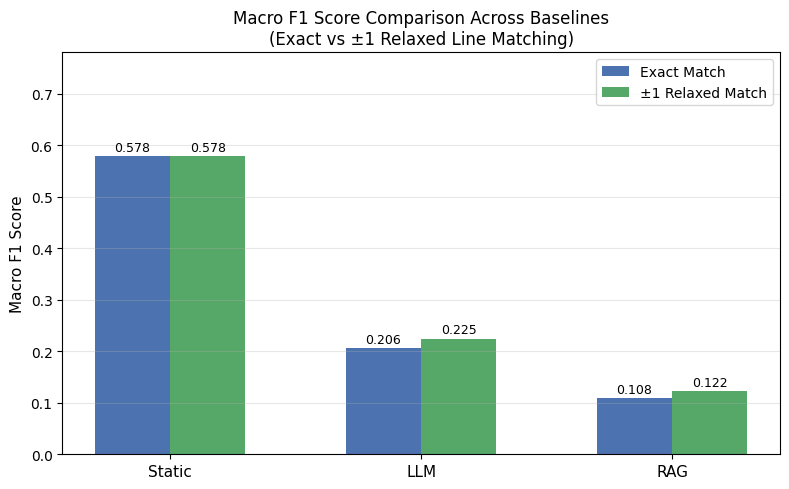

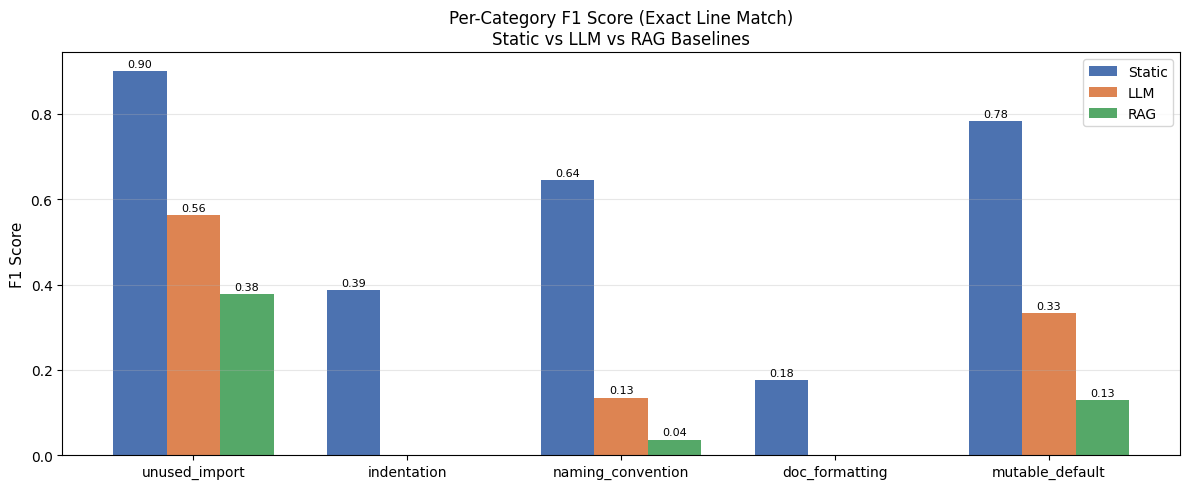

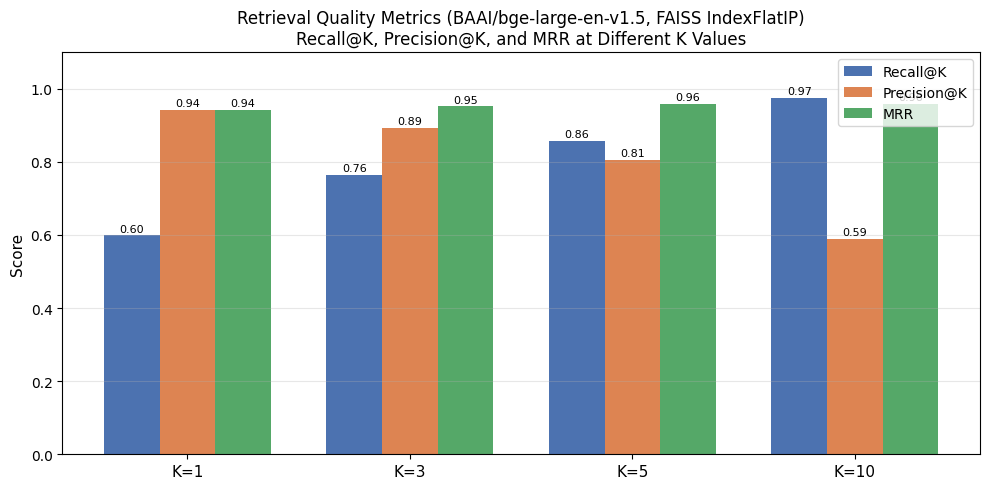

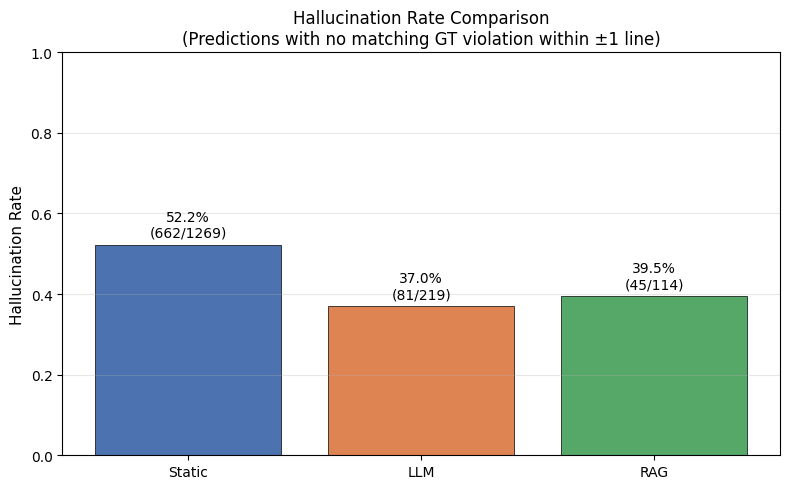

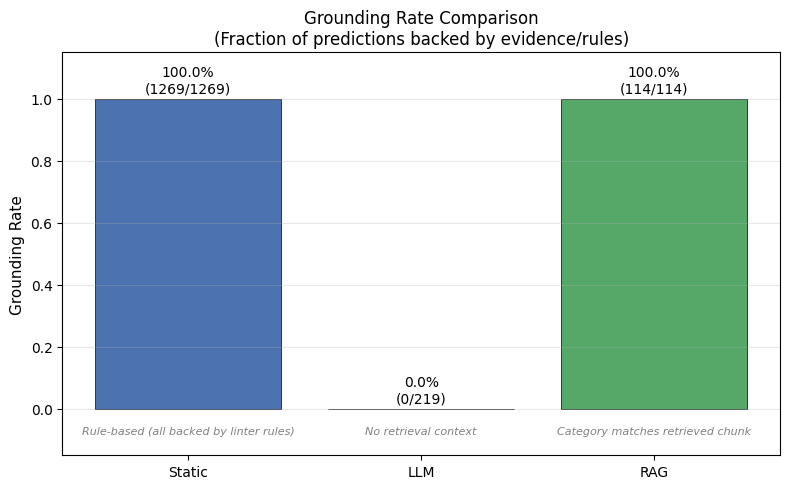

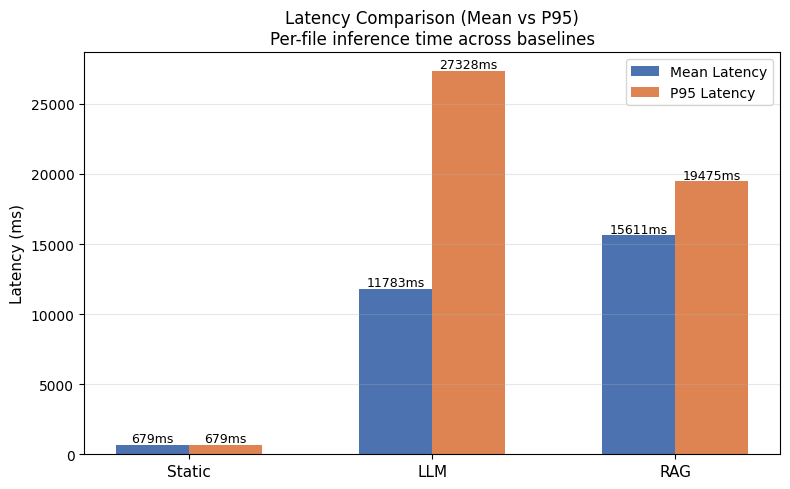

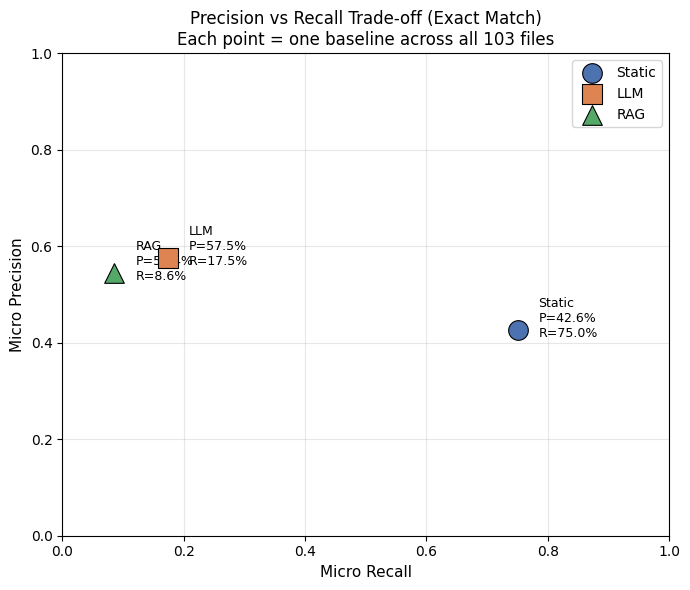

All plots saved to data/processed/


In [13]:

%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

bnames = ["Static", "LLM", "RAG"]
colors = ["#4C72B0", "#DD8452", "#55A868"]

# --- Plot 1: Macro F1 (exact vs relaxed) ---
fig, ax = plt.subplots(figsize=(8, 5))
exact_f1 = [all_scores[f"{n}_exact"]["macro_f1"] for n in bnames]
relaxed_f1 = [all_scores[f"{n}_relaxed"]["macro_f1"] for n in bnames]
x = np.arange(len(bnames))
bars1 = ax.bar(x - 0.15, exact_f1, 0.3, label="Exact Match", color="#4C72B0")
bars2 = ax.bar(x + 0.15, relaxed_f1, 0.3, label="±1 Relaxed Match", color="#55A868")
for b in bars1:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.3f}",
            ha="center", fontsize=9)
for b in bars2:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.3f}",
            ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(bnames, fontsize=11)
ax.set_ylabel("Macro F1 Score", fontsize=11)
ax.set_title("Macro F1 Score Comparison Across Baselines\n(Exact vs ±1 Relaxed Line Matching)", fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, max(exact_f1 + relaxed_f1) * 1.35)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(ROOT / "data" / "processed" / "plot_macro_f1.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- Plot 2: Per-category F1 (exact match) ---
fig, ax = plt.subplots(figsize=(12, 5))
cat_labels = ["unused_import", "indentation", "naming_convention", "doc_formatting", "mutable_default"]
width = 0.25
for j, (name, color) in enumerate(zip(bnames, colors)):
    vals = [all_scores[f"{name}_exact"]["per_category"][c]["f1"] for c in CATEGORIES]
    bars = ax.bar(np.arange(len(CATEGORIES)) + j * width, vals, width, label=name, color=color)
    for b in bars:
        if b.get_height() > 0.001:
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.2f}",
                    ha="center", fontsize=8)
ax.set_xticks(np.arange(len(CATEGORIES)) + width)
ax.set_xticklabels(cat_labels, fontsize=10)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_title("Per-Category F1 Score (Exact Line Match)\nStatic vs LLM vs RAG Baselines", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(ROOT / "data" / "processed" / "plot_per_category_f1.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- Plot 3: Retrieval Recall@K, Precision@K, MRR ---
fig, ax = plt.subplots(figsize=(10, 5))
ks = [1, 3, 5, 10]
recalls = [ret_metrics[k]["recall"] for k in ks]
precisions = [ret_metrics[k]["precision"] for k in ks]
mrrs = [ret_metrics[k]["mrr"] for k in ks]
x_k = np.arange(len(ks))
w = 0.25
bars_r = ax.bar(x_k - w, recalls, w, label="Recall@K", color="#4C72B0")
bars_p = ax.bar(x_k, precisions, w, label="Precision@K", color="#DD8452")
bars_m = ax.bar(x_k + w, mrrs, w, label="MRR", color="#55A868")
for bars in [bars_r, bars_p, bars_m]:
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01, f"{b.get_height():.2f}",
                ha="center", fontsize=8)
ax.set_xticks(x_k)
ax.set_xticklabels([f"K={k}" for k in ks], fontsize=11)
ax.set_ylabel("Score", fontsize=11)
ax.set_title("Retrieval Quality Metrics (BAAI/bge-large-en-v1.5, FAISS IndexFlatIP)\nRecall@K, Precision@K, and MRR at Different K Values", fontsize=12)
ax.legend(fontsize=10)
ax.set_ylim(0, 1.1)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(ROOT / "data" / "processed" / "plot_retrieval_quality.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- Plot 4: Hallucination Rate ---
fig, ax = plt.subplots(figsize=(8, 5))
hall_data = {}
for name, preds_m in [("Static", static_preds), ("LLM", llm_preds), ("RAG", rag_preds)]:
    h, t = hallucination_rate(preds_m, eval_data)
    hall_data[name] = {"hallucinated": h, "total": t, "rate": h / t if t > 0 else 0}
hall_vals = [hall_data[n]["rate"] for n in bnames]
bars = ax.bar(bnames, hall_vals, color=colors, edgecolor="black", linewidth=0.5)
for i, b in enumerate(bars):
    n = bnames[i]
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
            f"{hall_data[n]['rate']:.1%}\n({hall_data[n]['hallucinated']}/{hall_data[n]['total']})",
            ha="center", fontsize=10)
ax.set_ylabel("Hallucination Rate", fontsize=11)
ax.set_title("Hallucination Rate Comparison\n(Predictions with no matching GT violation within ±1 line)", fontsize=12)
ax.set_ylim(0, 1.0)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(ROOT / "data" / "processed" / "plot_hallucination.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- Plot 5: Grounding Rate ---
# Static: 100% grounded (every prediction comes from a deterministic linter rule)
# LLM: 0% grounded (no retrieved context available)
# RAG: check if predicted category matches any retrieved chunk category
g_rag, t_rag = grounding_rate(rag_preds, rag_raw_chunks, eval_data)
ground_data = {
    "Static": {"grounded": sum(len(v) for v in static_preds.values()),
               "total": sum(len(v) for v in static_preds.values()),
               "rate": 1.0, "reason": "Rule-based (all backed by linter rules)"},
    "LLM": {"grounded": 0, "total": sum(len(v) for v in llm_preds.values()),
             "rate": 0.0, "reason": "No retrieval context"},
    "RAG": {"grounded": g_rag, "total": t_rag,
            "rate": g_rag / t_rag if t_rag > 0 else 0, "reason": "Category matches retrieved chunk"},
}

fig, ax = plt.subplots(figsize=(8, 5))
ground_vals = [ground_data[n]["rate"] for n in bnames]
bars = ax.bar(bnames, ground_vals, color=colors, edgecolor="black", linewidth=0.5)
for i, b in enumerate(bars):
    n = bnames[i]
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.02,
            f"{ground_data[n]['rate']:.1%}\n({ground_data[n]['grounded']}/{ground_data[n]['total']})",
            ha="center", fontsize=10)
    ax.text(b.get_x() + b.get_width()/2, -0.08, ground_data[n]["reason"],
            ha="center", fontsize=8, style="italic", color="gray")
ax.set_ylabel("Grounding Rate", fontsize=11)
ax.set_title("Grounding Rate Comparison\n(Fraction of predictions backed by evidence/rules)", fontsize=12)
ax.set_ylim(-0.15, 1.15)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(ROOT / "data" / "processed" / "plot_grounding.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- Plot 6: Latency Comparison ---
fig, ax = plt.subplots(figsize=(8, 5))
mean_vals = [static_per_file, mean_val(llm_lat), mean_val(rag_lat)]
p95_vals = [static_per_file, p95_val(llm_lat), p95_val(rag_lat)]
bars1 = ax.bar(x - 0.15, mean_vals, 0.3, label="Mean Latency", color="#4C72B0")
bars2 = ax.bar(x + 0.15, p95_vals, 0.3, label="P95 Latency", color="#DD8452")
for b in bars1:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 200,
            f"{b.get_height():.0f}ms", ha="center", fontsize=9)
for b in bars2:
    ax.text(b.get_x() + b.get_width()/2, b.get_height() + 200,
            f"{b.get_height():.0f}ms", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(bnames, fontsize=11)
ax.set_ylabel("Latency (ms)", fontsize=11)
ax.set_title("Latency Comparison (Mean vs P95)\nPer-file inference time across baselines", fontsize=12)
ax.legend(fontsize=10)
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.savefig(str(ROOT / "data" / "processed" / "plot_latency.png"), dpi=150, bbox_inches="tight")
plt.show()

# --- Plot 7: Precision vs Recall scatter ---
fig, ax = plt.subplots(figsize=(7, 6))
markers = ["o", "s", "^"]
for nm, marker, color in zip(bnames, markers, colors):
    s = all_scores[f"{nm}_exact"]
    ax.scatter(s["micro_recall"], s["micro_precision"], s=200, marker=marker,
               color=color, label=nm, zorder=5, edgecolors="black", linewidth=0.8)
    ax.annotate(f'{nm}\nP={s["micro_precision"]:.1%}\nR={s["micro_recall"]:.1%}',
                (s["micro_recall"], s["micro_precision"]),
                textcoords="offset points", xytext=(15, -5), fontsize=9)
ax.set_xlabel("Micro Recall", fontsize=11)
ax.set_ylabel("Micro Precision", fontsize=11)
ax.set_title("Precision vs Recall Trade-off (Exact Match)\nEach point = one baseline across all 103 files", fontsize=12)
ax.legend(fontsize=10)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(str(ROOT / "data" / "processed" / "plot_precision_recall.png"), dpi=150, bbox_inches="tight")
plt.show()

print("All plots saved to data/processed/")
